# Generate full paper-style visualization data

Running `pig_vi.py`, we run value iteration on the full game of Pig with target score $=100$. We store the policy as `pig_full_policy.pkl` and the full solution as `pig_full_solution.pkl`. 

In this notebook, we transform the data objects and generate figures corresponding to the paper's main visualizations:

- Figure 3: roll/hold boundary,
- Figure 4: cross-section at opponent score 30,
- Figure 5: reachable states,
- Figure 6: reachable states where rolling is optimal,
- Figure 7: win-probability contours at 3%, 9%, 27%, and 81%.

(Note that Figure 7 requires the full value table `full_V`. If only `pig_full_policy.pkl` is available, Figures 3-6 still work and Figure 7 is skipped.)

## 1. Run value iteration

In [1]:
# Import modules
from pathlib import Path
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../')

from src.optimal_pig import piglet
from src.optimal_pig import pig
from src.optimal_pig import value_iteration_fun as vi
from src.optimal_pig import analysis_helpers as ah

print("Imported modules successfully.")

Imported modules successfully.


## 1.1. Generate or load in pig policy and solution

Running the first chunk will run value iteration on pig and will store the required policy and solution files. As these are available as pickle files in the same folder, it may not be necessary to run this chunk.

As these files are used to generate the complimentary figures to the paper, we use $0\le k < G$. To speed up the code, it is possible to run $0 \le k < G-i$ by switching to `restricted_k = True`. See the example pig notebook for more details.

In [2]:
# Generate policy (this takes about 15 minutes)
run = False

if run:
    %run pig_vi.py 

The following chunk will load in the saved pickle objects.

In [3]:
# Load in files
import pickle
from pathlib import Path

RUN_FULL_PIG = False
restricted_k = False
full_pig_spec = pig.make_spec(target_score=100)

solution_path = Path("pig_full_solution.pkl")
policy_path = Path("pig_full_policy.pkl")

full_V = None

if solution_path.exists():
    with solution_path.open("rb") as f:
        full_solution = pickle.load(f)

    full_policy = full_solution["policy"]
    full_V = full_solution.get("V")
    restricted_k = bool(full_solution.get("restricted_k", False))
    target_score = int(full_solution.get("target_score", 100))
    full_pig_spec = pig.make_spec(target_score=target_score)
    print(f"Loaded full solution from {solution_path}")

elif policy_path.exists():
    with policy_path.open("rb") as f:
        full_policy = pickle.load(f)

    print(f"Loaded full policy from {policy_path}")
    print("No full value table was found; Figure 7 will be skipped.")

else:
    raise FileNotFoundError(
        "Run the full Pig solve once, or place pig_full_policy.pkl / "
        "pig_full_solution.pkl in the notebook directory."
    )

print("Full policy shape:", full_policy.shape)
print("restricted_k:", restricted_k)

Loaded full solution from pig_full_solution.pkl
Full policy shape: (100, 100, 100)
restricted_k: False


## 1.2. Transform data for figures

In [4]:
# Change data format for figures
full_fig3_data = ah.figure3_boundary_data(
    full_policy,
    include_terminal_boundary=True,
)

full_fig5_data = ah.figure5_reachable_data(
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)

full_fig4_data = ah.figure4_cross_section_data(
    full_policy,
    opponent_score=30,
    spec=full_pig_spec,
    reachable=full_fig5_data["reachable"],
    restricted_k=restricted_k,
)

full_fig6_data = ah.figure6_reachable_continue_data(
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)

if full_V is not None:
    full_fig7_data = ah.figure7_probability_contour_data(
        full_pig_spec,
        full_V,
        levels=(0.03, 0.09, 0.27, 0.81),
        restricted_k=restricted_k,
    )
else:
    full_fig7_data = None

print("Full Figure 3 boundary points:", full_fig3_data["points"].shape)
print("Full Figure 4 transition points:", full_fig4_data["transition_points"].shape)
print("Full Figure 5 reachable points:", full_fig5_data["points"].shape)
print("Full Figure 6 reachable-roll points:", full_fig6_data["points"].shape)
if full_fig7_data is None:
    print("Full Figure 7 data skipped because full_V is not available.")

Full Figure 3 boundary points: (9984, 3)
Full Figure 4 transition points: (134, 5)
Full Figure 5 reachable points: (179577, 3)
Full Figure 6 reachable-roll points: (160879, 3)


# 2. Figure 3

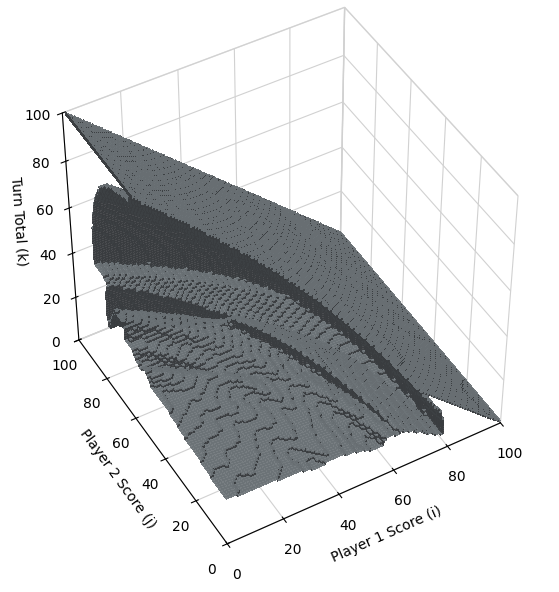

In [5]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ah.plot_figure3_policy_boundary(
    full_fig3_data,
    ax=ax,
    boundary_alpha=0.92,
)

ax.view_init(elev=45, azim=240)
plt.savefig("Figures/Figure3a.png", bbox_inches='tight', dpi=300)
plt.show()

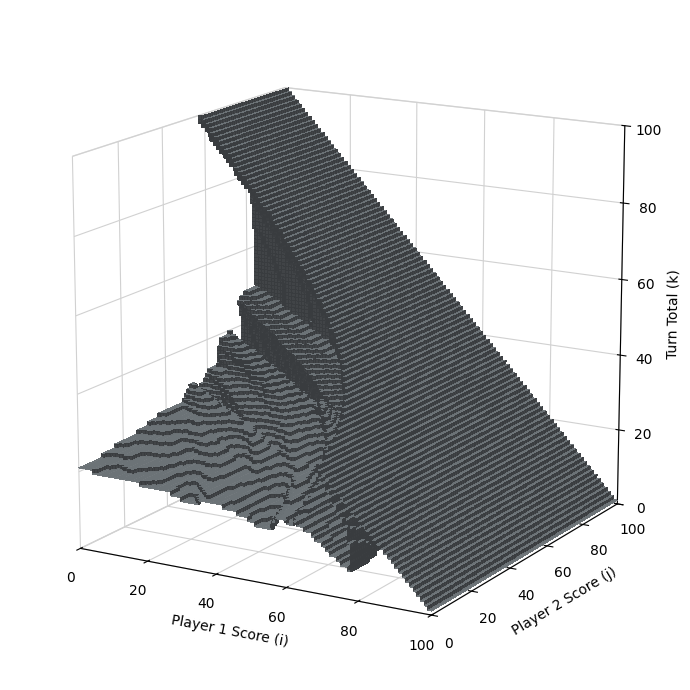

In [6]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ah.plot_figure3_policy_boundary(
    full_fig3_data,
    ax=ax,
    boundary_alpha=0.96,
    max_surface_jump=100,
)

ax.view_init(elev=15, azim=-60)
plt.savefig("Figures/Figure3b.png", bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

# 3. Figure 4

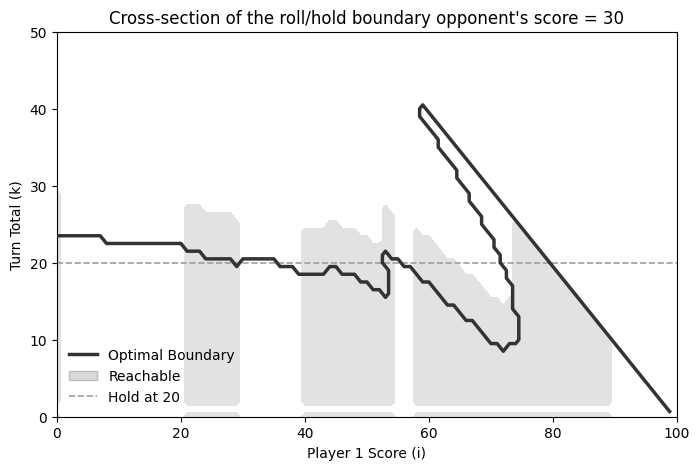

In [7]:
ah.plot_figure4_cross_section(
    full_fig4_data,
    hold_at_threshold=20,
    title="Cross-section of the roll/hold boundary opponent's score = 30"
)
plt.ylim(0, 50)
plt.xlim(0, 100)
plt.savefig("Figures/Figure4.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. Figure 5

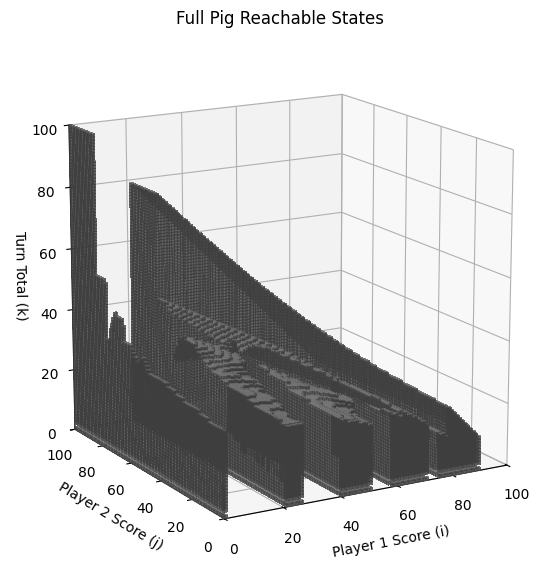

In [8]:
ax = ah.plot_figure5_reachable_states(
    full_fig5_data,
    max_points=60000,
    title="Full Pig Reachable States"
)
ax.view_init(elev=15, azim=240)
plt.savefig("Figures/Figure5a.png", bbox_inches='tight', dpi=300)
plt.show()

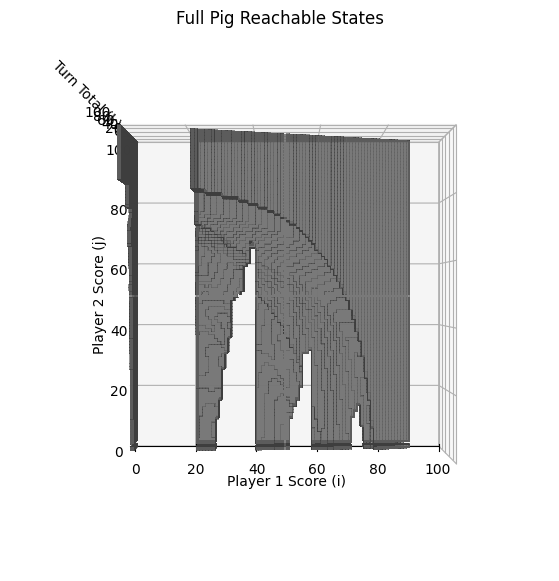

In [9]:
ax = ah.plot_figure5_reachable_states(
    full_fig5_data,
    max_points=60000,
    title="Full Pig Reachable States"
)
ax.view_init(elev=90, azim=-90)
plt.savefig("Figures/Figure5b.png", bbox_inches='tight', dpi=300)
plt.show()

# 4. Figure 6

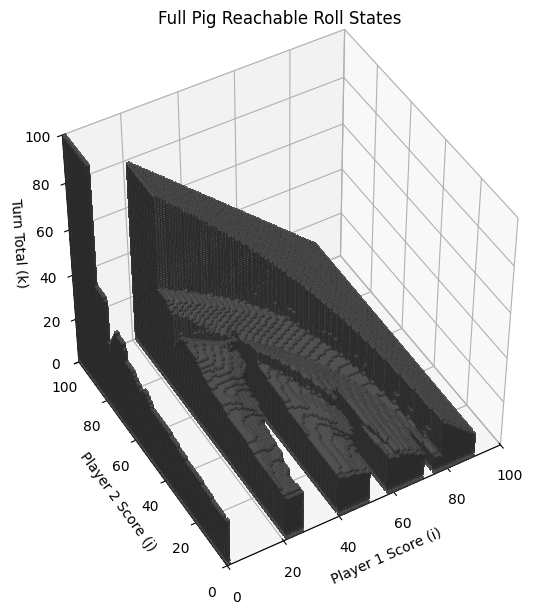

In [10]:
ax = ah.plot_figure6_reachable_continue_states(
    full_fig6_data,
    max_points=60000,
    title="Full Pig Reachable Roll States"
)
ax.view_init(elev=45, azim=240)
plt.savefig("Figures/Figure6.png", bbox_inches='tight', dpi=300)
plt.show()

# 5. Figure 7

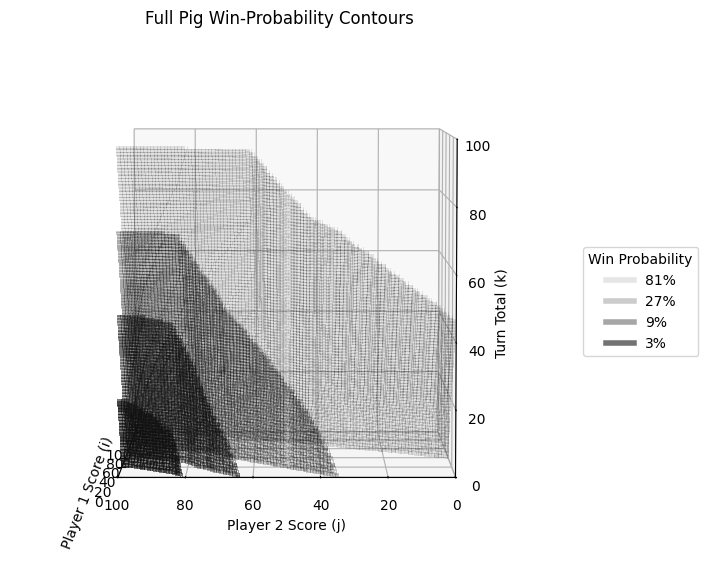

In [11]:
ax = ah.plot_figure7_probability_contours(
    full_fig7_data,
    title="Full Pig Win-Probability Contours"
)

ax.view_init(elev=5, azim=180)

ah.add_3d_contour_legend(
    ax,
    [0.81, 0.27, 0.09, 0.03]
)

plt.savefig("Figures/Figure7.png", bbox_inches="tight", dpi=300)
plt.show()